**Netflix Content Strategy Analyzer: Insights into Global Streaming Trends**

In [299]:
import pandas as pd
import kagglehub
import matplotlib as plt


In [300]:
# Download latest version
path = kagglehub.dataset_download("shivamb/netflix-shows")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'netflix-shows' dataset.
Path to dataset files: /kaggle/input/netflix-shows


In [301]:
df = pd.read_csv("/kaggle/input/netflix-shows/netflix_titles.csv")

In [302]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [303]:
df.shape

(8807, 12)

In [304]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [305]:

df[df.duplicated()].sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


In [306]:
df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,int64
rating,object
duration,object


# **Data cleaning**

# Handling null, missing and inconsistent categories

In [307]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

In [308]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,10
release_year,0
rating,4
duration,3


In [309]:
df = df.dropna(subset=['rating'])
df = df.dropna(subset=['duration'])
df = df.dropna(subset=['date_added'])

In [310]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


**Handle Inconsistent Columns**

In [311]:
df=df.rename(columns={"listed_in":"genre"})

In [312]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genre,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# **NORMALIZATION**

In [313]:
# df['genre'] = df['genre'].str.split(',')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genre,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [314]:

df = df.explode('genre')
df['genre'] = df['genre'].str.strip()
df['genre'] = df['genre'].str.title()

In [315]:
#remove any leading or trailing spaces
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

In [316]:
#to lower case
df = df.apply(lambda x: x.str.lower() if x.dtype == "object" else x)

In [317]:
# Convert date_added to datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

df['release_year'] = pd.to_numeric(df['release_year'], errors='coerce')



/tmp/ipykernel_16660/51712857.py:2: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



In [318]:
df['duration_minutes'] = df['duration'].where(df['type'] == 'movie')
df['seasons'] = df['duration'].where(df['type'] == 'tv show')


In [319]:
df['seasons'] = df['seasons'].str.extract(r'(\d+)').astype(float)
df['duration_minutes'] = df['duration_minutes'].str.extract(r'(\d+)').astype(float)

In [320]:
df['seasons'] = df['seasons'].fillna('Unknown')
df['duration_minutes'] = df['duration_minutes'].fillna('Unknown')

In [321]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genre,description,duration_minutes,seasons
0,s1,movie,dick johnson is dead,kirsten johnson,unknown,united states,2021-09-25,2020,pg-13,90 min,documentaries,"as her father nears the end of his life, filmm...",90.0,Unknown
1,s2,tv show,blood & water,unknown,"ama qamata, khosi ngema, gail mabalane, thaban...",south africa,2021-09-24,2021,tv-ma,2 seasons,"international tv shows, tv dramas, tv mysteries","after crossing paths at a party, a cape town t...",Unknown,2.0
2,s3,tv show,ganglands,julien leclercq,"sami bouajila, tracy gotoas, samuel jouy, nabi...",unknown,2021-09-24,2021,tv-ma,1 season,"crime tv shows, international tv shows, tv act...",to protect his family from a powerful drug lor...,Unknown,1.0
3,s4,tv show,jailbirds new orleans,unknown,unknown,unknown,2021-09-24,2021,tv-ma,1 season,"docuseries, reality tv","feuds, flirtations and toilet talk go down amo...",Unknown,1.0
4,s5,tv show,kota factory,unknown,"mayur more, jitendra kumar, ranjan raj, alam k...",india,2021-09-24,2021,tv-ma,2 seasons,"international tv shows, romantic tv shows, tv ...",in a city of coaching centers known to train i...,Unknown,2.0


In [322]:
df = df.dropna(subset=['genre'])
df = df.reset_index(drop=True)


In [323]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


# Analyze Netflix content growth over time.

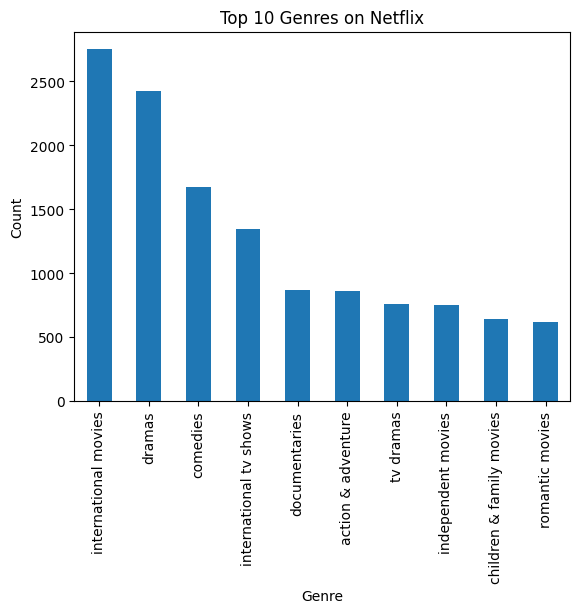

In [324]:
import matplotlib.pyplot as plt

genre = df['genre'].str.split(',', expand=True).stack().str.strip()

genre.value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()

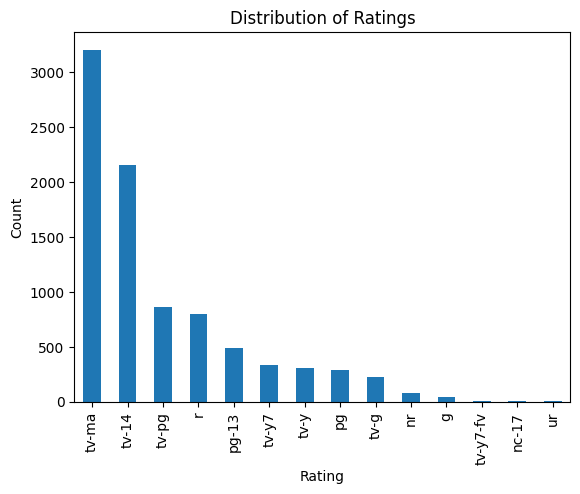

In [325]:
df['rating'].value_counts().plot(kind='bar')

plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

In [326]:
df['country'].str.contains(',').sum()

np.int64(1320)

In [327]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


<Axes: title={'center': 'Netflix Content Growth Over Time'}, xlabel='year_added'>

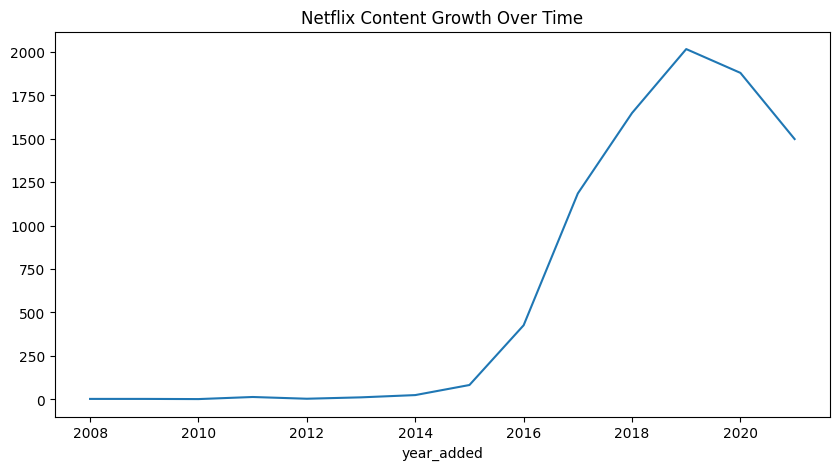

In [328]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

df['year_added'] = df['date_added'].dt.year
content_growth = df.groupby('year_added')['show_id'].count()

content_growth.plot(kind='line', figsize=(10,5), title="Netflix Content Growth Over Time")

<Axes: title={'center': 'Distribution of Content Type'}, xlabel='type'>

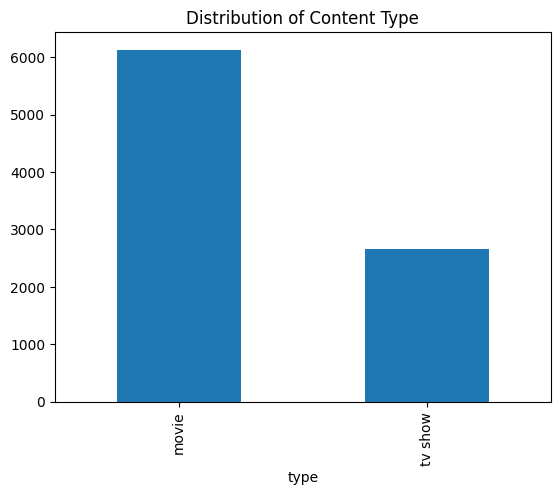

In [329]:
df['type'].value_counts().plot(kind='bar', title='Distribution of Content Type')

<Axes: title={'center': 'Top Content Producing Countries'}, xlabel='country'>

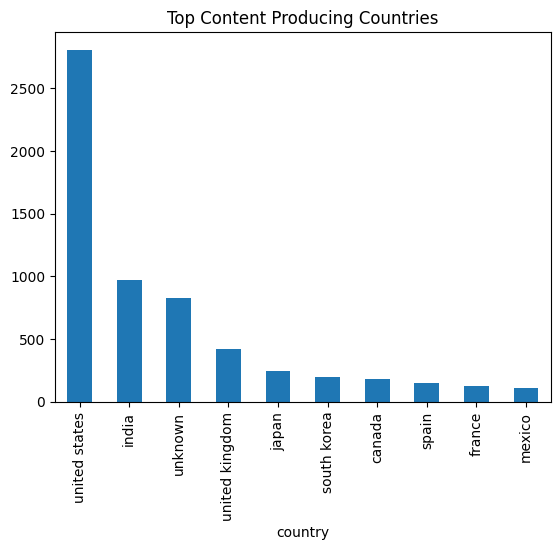

In [330]:
countries=df['country']

top_countries = countries.value_counts().head(10)

top_countries.plot(kind='bar', title='Top Content Producing Countries')

# Feature Engineering

In [331]:
df['duration_num'] = df['duration'].str.extract(r'(\d+)').astype(float)

In [332]:
def length_category(row):

    if row['type'] == 'Movie':
        if row['duration_num'] < 60:
            return 'Short'
        elif row['duration_num'] < 120:
            return 'Medium'
        else:
            return 'Long'

    else:
        if row['duration_num'] == 1:
            return 'Single Season'
        else:
            return 'Multi Season'

df['content_length_category'] = df.apply(length_category, axis=1)

In [333]:
df['is_netflix_original'] = df['title'].str.contains('Netflix', case=False, na=False)

In [334]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   show_id                  8790 non-null   object        
 1   type                     8790 non-null   object        
 2   title                    8790 non-null   object        
 3   director                 8790 non-null   object        
 4   cast                     8790 non-null   object        
 5   country                  8790 non-null   object        
 6   date_added               8790 non-null   datetime64[ns]
 7   release_year             8790 non-null   int64         
 8   rating                   8790 non-null   object        
 9   duration                 8790 non-null   object        
 10  genre                    8790 non-null   object        
 11  description              8790 non-null   object        
 12  duration_minutes         8790 non-

# Clustering to group Netflix titles by genre, duration, and ratings.

In [335]:
# Import required libraries
from sklearn.preprocessing import LabelEncoder
import pandas as pd

In [336]:
# Encode rating column into numeric values
le_rating = LabelEncoder()
df['rating_encoded'] = le_rating.fit_transform(df['rating'].astype(str))

In [337]:
# Extract primary genre (first genre listed)
df['primary_genre'] = df['genre'].str.split(',').str[0]

In [338]:
# Encode genre column
le_genre = LabelEncoder()
df['genre_encoded'] = le_genre.fit_transform(df['primary_genre'])

***Clustering Netflix Titles***

In [339]:
from sklearn.cluster import KMeans

In [340]:
# Select clustering features
X_cluster = df[['duration_num','rating_encoded','genre_encoded']].dropna()

In [341]:
# Initialize KMeans model
kmeans = KMeans(n_clusters=5, random_state=42)

In [342]:
# Fit model and assign cluster labels
df.loc[X_cluster.index, 'cluster'] = kmeans.fit_predict(X_cluster)

In [343]:
# Check number of titles in each cluster
df['cluster'].value_counts()

,count
cluster,
2.0,3164
1.0,2805
3.0,1576
0.0,861
4.0,384


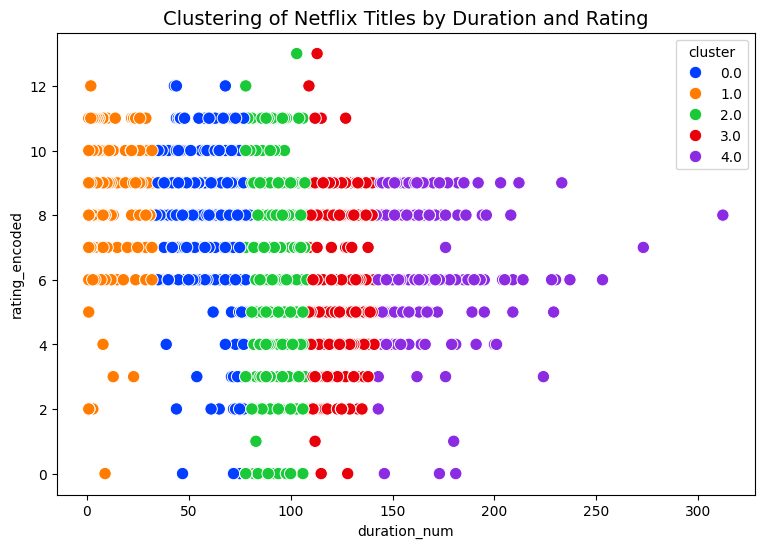

In [344]:
import seaborn as sns
plt.figure(figsize=(9,6))

sns.scatterplot(
    x='duration_num',
    y='rating_encoded',
    hue='cluster',
    palette='bright',
    data=df,
    s=80
)

plt.title("Clustering of Netflix Titles by Duration and Rating", fontsize=14)

plt.show()

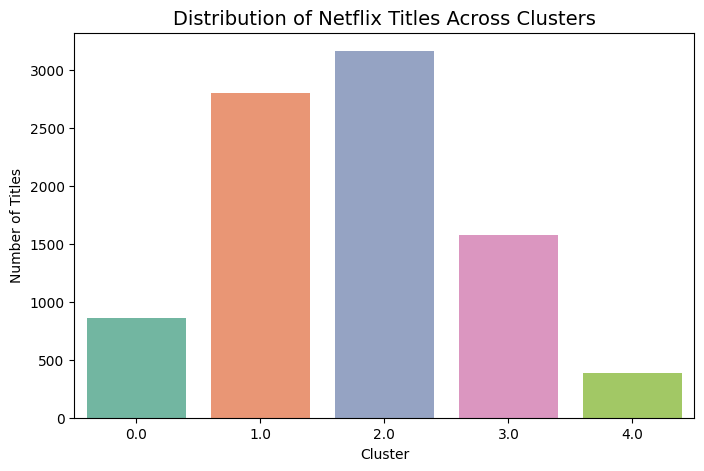

In [345]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

# Fixed: Assigned 'cluster' to hue and disabled the redundant legend
sns.countplot(
    x='cluster',
    data=df,
    hue='cluster',
    palette='Set2',
    legend=False
)

plt.title("Distribution of Netflix Titles Across Clusters", fontsize=14)
plt.xlabel("Cluster")
plt.ylabel("Number of Titles")

plt.show()

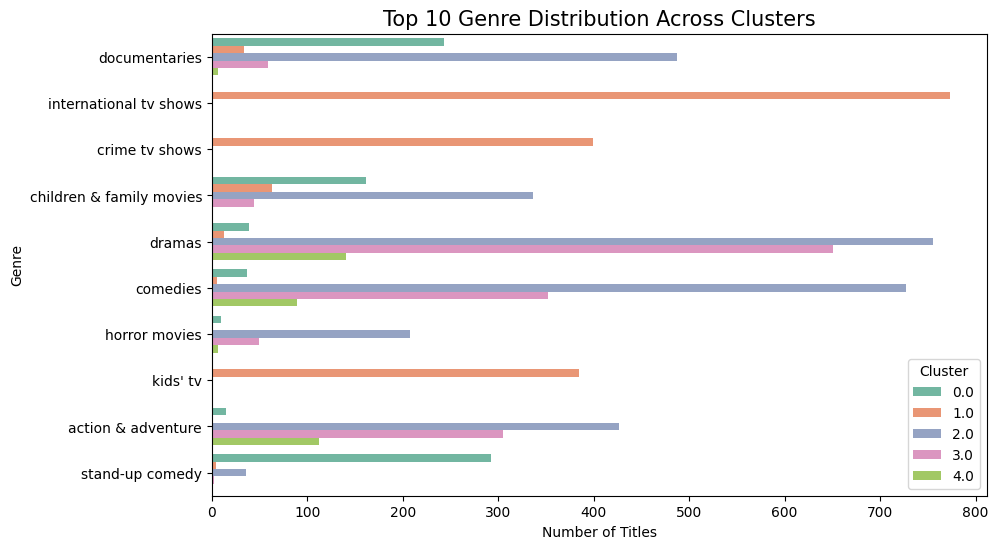

In [346]:
# Get top 10 most frequent genres
top_genres = df['primary_genre'].value_counts().head(10).index

# Filter dataset
df_top = df[df['primary_genre'].isin(top_genres)]

plt.figure(figsize=(10,6))

sns.countplot(
    y='primary_genre',
    hue='cluster',
    data=df_top,
    palette='Set2'
)

plt.title("Top 10 Genre Distribution Across Clusters", fontsize=15)
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.legend(title="Cluster")

plt.show()

# Classification Model (Movie vs TV Show)

In [347]:
# Select features for classification
X = df[['duration_num','rating_encoded','genre_encoded']].dropna()

# Target variable
y = df.loc[X.index,'type'].map({'movie':0,'tv show':1})

In [348]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [349]:
from sklearn.ensemble import RandomForestClassifier

# Initialize classifier
model = RandomForestClassifier(random_state=42)

# Train the model
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [350]:
# Predict on test data
y_pred = model.predict(X_test)

# Calculate accuracy
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

1.0

In [351]:
# Calculate feature importance
importance = pd.Series(model.feature_importances_, index=X.columns)

# Sort importance values
importance.sort_values(ascending=False)

,0
duration_num,0.751264
genre_encoded,0.200150
rating_encoded,0.048586


In [352]:
# Predict values
y_pred = model.predict(X_test)

# Classification report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1227
           1       1.00      1.00      1.00       531

    accuracy                           1.00      1758
   macro avg       1.00      1.00      1.00      1758
weighted avg       1.00      1.00      1.00      1758



**Country vs Genre Heatmap**                                                               
This shows which genres are most common in which countries.

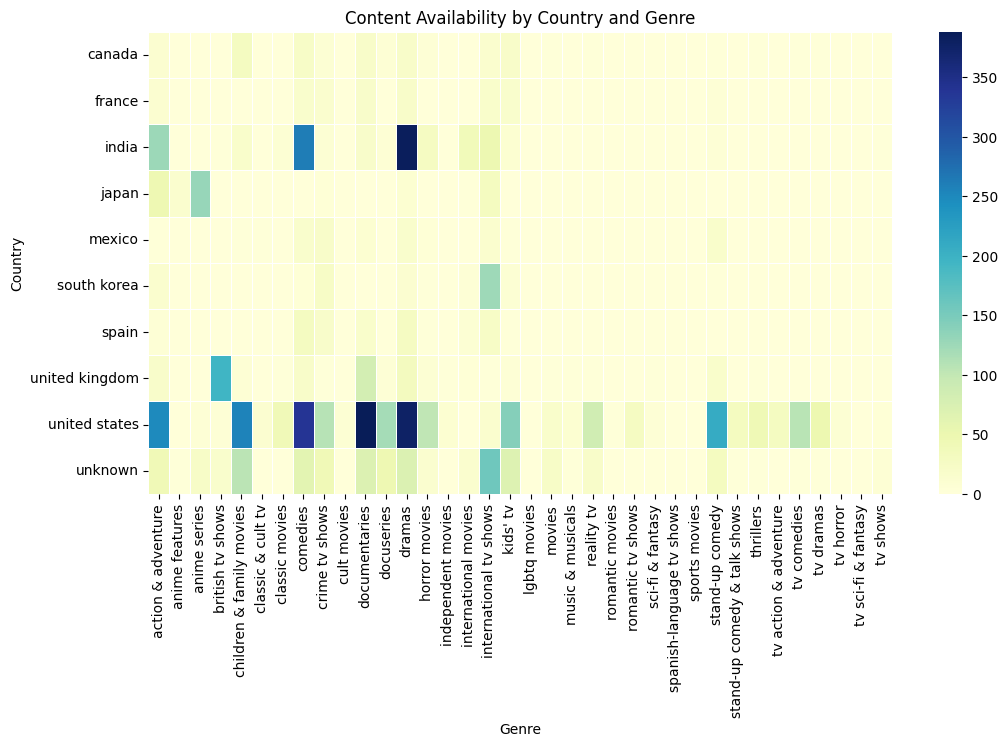

In [353]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get top countries
top_countries = df['country'].value_counts().head(10).index

# Filter dataset
df_country = df[df['country'].isin(top_countries)]

# Create country vs genre table
country_genre = pd.crosstab(df_country['country'], df_country['primary_genre'])

plt.figure(figsize=(12,6))

sns.heatmap(
    country_genre,
    cmap='YlGnBu',
    linewidths=0.5
)

plt.title("Content Availability by Country and Genre")

plt.xlabel("Genre")
plt.ylabel("Country")

plt.show()

/tmp/ipykernel_16660/1141211088.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




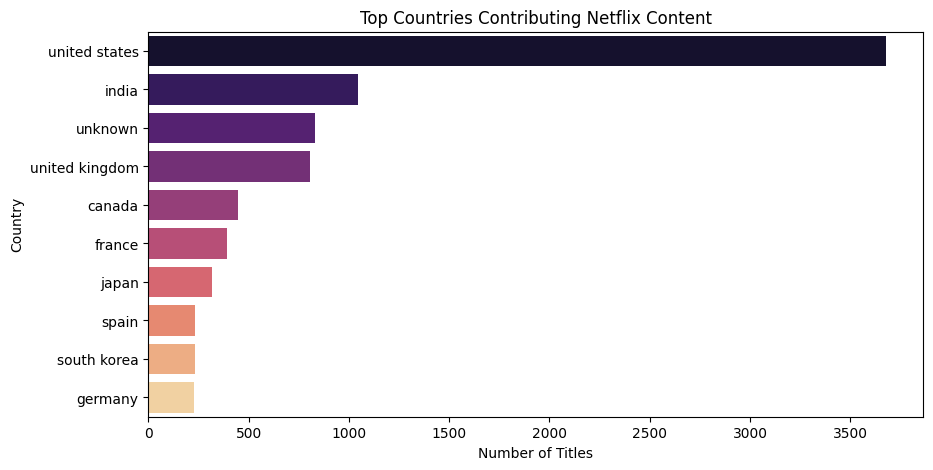

In [354]:
countries = df['country'].str.split(',', expand=True).stack().str.strip()

top_countries = countries.value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    palette='magma'
)

plt.title("Top Countries Contributing Netflix Content")

plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.show()

***Confusion Matrix***

In [355]:
y_pred = model.predict(X_test)
from sklearn.metrics import confusion_matrix

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

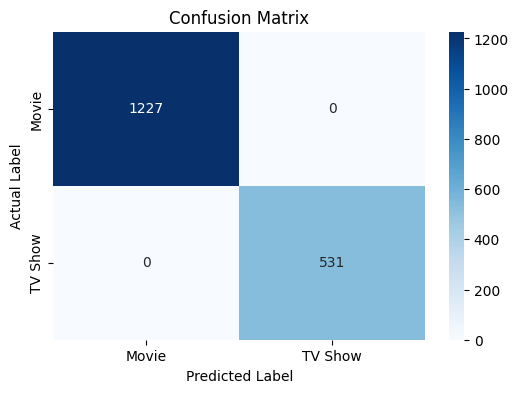

In [356]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Movie','TV Show'],
    yticklabels=['Movie','TV Show']
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

# *** Feature importance methods to interpret results.***

/tmp/ipykernel_16660/2807416917.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




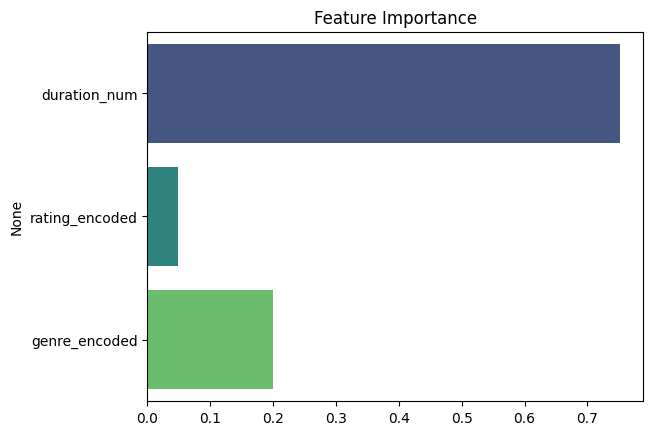

In [357]:
import seaborn as sns

sns.barplot(
    x=importance.values,
    y=importance.index,
    palette='viridis'
)

plt.title("Feature Importance")
plt.show()

In [358]:
# Create primary_country from country column
df['primary_country'] = df['country'].str.split(',').str[0].str.strip()
# Get top 10 countries
top_countries = df['primary_country'].value_counts().head(10).index

df_top = df[df['primary_country'].isin(top_countries)]

# Find top genre for each country
top_genre_country = (
    df_top.groupby(['primary_country', 'primary_genre'])
    .size()
    .reset_index(name='count')
)

# Get top genre per country
top_genre_country = top_genre_country.sort_values(
    ['primary_country', 'count'],
    ascending=[True, False]
).drop_duplicates('primary_country')

In [359]:
import plotly.express as px

fig = px.bar(
    top_genre_country,
    x='count',
    y='primary_country',
    color='primary_genre',
    title="Top Genre per Country",
    color_discrete_sequence=px.colors.qualitative.Bold
)

fig.show()